In [6]:
import matplotlib.pyplot as plt
import numpy as np

In [93]:
num_steps = 100
beta_start = 1e-4
beta_end = 0.5

## Schedule Comparison

In [94]:
from src.model import _DiffusionBase

betas_linear = np.linspace(beta_start, beta_end, num_steps)
betas_quadratic = np.linspace(beta_start**0.5, beta_end**0.5, num_steps) ** 2
betas_cosine = _DiffusionBase.cosine_beta_schedule(num_steps)

betas_list = [betas_linear, betas_quadratic, betas_cosine]
alphas_list = [1 - betas for betas in betas_list]
alpha_bar_list = [np.cumprod(alphas) for alphas in alphas_list]

print([alpha_bar[-1] for alpha_bar in alpha_bar_list])
print([np.sqrt(alpha_bar[-1]) for alpha_bar in alpha_bar_list])

[np.float64(4.5025411029239424e-14), np.float64(1.3051071228707825e-09), np.float64(2.427676254416856e-07)]
[np.float64(2.1219192027322676e-07), np.float64(3.6126266384319076e-05), np.float64(0.0004927145476253828)]


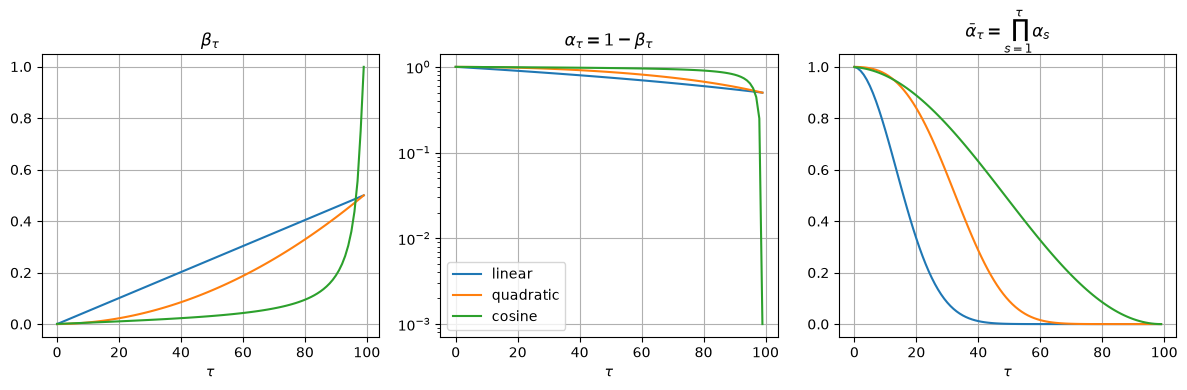

In [86]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
ax0, ax1, ax2 = axs

schedules = ["linear", "quadratic", "cosine"]

ax0.set_title(r"$\beta_\tau$")
for betas in betas_list:
    ax0.plot(betas)
# ax0.semilogy()

ax1.set_title(r"$\alpha_\tau = 1 - \beta_\tau$")
for alphas, schedule in zip(alphas_list, schedules, strict=True):
    ax1.plot(alphas, label=schedule)
ax1.semilogy()
ax1.legend()

ax2.set_title(r"$\bar{\alpha}_\tau = \prod_{s=1}^\tau \alpha_s$")
for alpha_bar in alpha_bar_list:
    ax2.plot(alpha_bar)

for ax in axs:
    ax.set_xlabel(r"$\tau$")
    ax.grid()

plt.tight_layout()
plt.show()

## `beta_end` Comparison

Final alpha_bar and sqrt(alpha_bar) values:

num_steps=100:
['beta_end=0.05: 0.1687, 0.4108', 'beta_end=0.1: 0.02821, 0.168', 'beta_end=0.15: 0.004475, 0.06689', 'beta_end=0.2: 0.0006677, 0.02584', 'beta_end=0.25: 9.305e-05, 0.009646', 'beta_end=0.5: 1.305e-09, 3.613e-05']

num_steps=150:
['beta_end=0.05: 0.0696, 0.2638', 'beta_end=0.1: 0.004781, 0.06914', 'beta_end=0.15: 0.0003036, 0.01742', 'beta_end=0.2: 1.76e-05, 0.004195', 'beta_end=0.25: 9.214e-07, 0.0009599', 'beta_end=0.5: 5.073e-14, 2.252e-07']

num_steps=200:
['beta_end=0.05: 0.0287, 0.1694', 'beta_end=0.1: 0.00081, 0.02846', 'beta_end=0.15: 2.059e-05, 0.004538', 'beta_end=0.2: 4.637e-07, 0.000681', 'beta_end=0.25: 9.123e-09, 9.552e-05', 'beta_end=0.5: 1.971e-18, 1.404e-09']

num_steps=250:
['beta_end=0.05: 0.01184, 0.1088', 'beta_end=0.1: 0.0001372, 0.01172', 'beta_end=0.15: 1.397e-06, 0.001182', 'beta_end=0.2: 1.222e-08, 0.0001105', 'beta_end=0.25: 9.033e-11, 9.504e-06', 'beta_end=0.5: 7.658e-23, 8.751e-12']


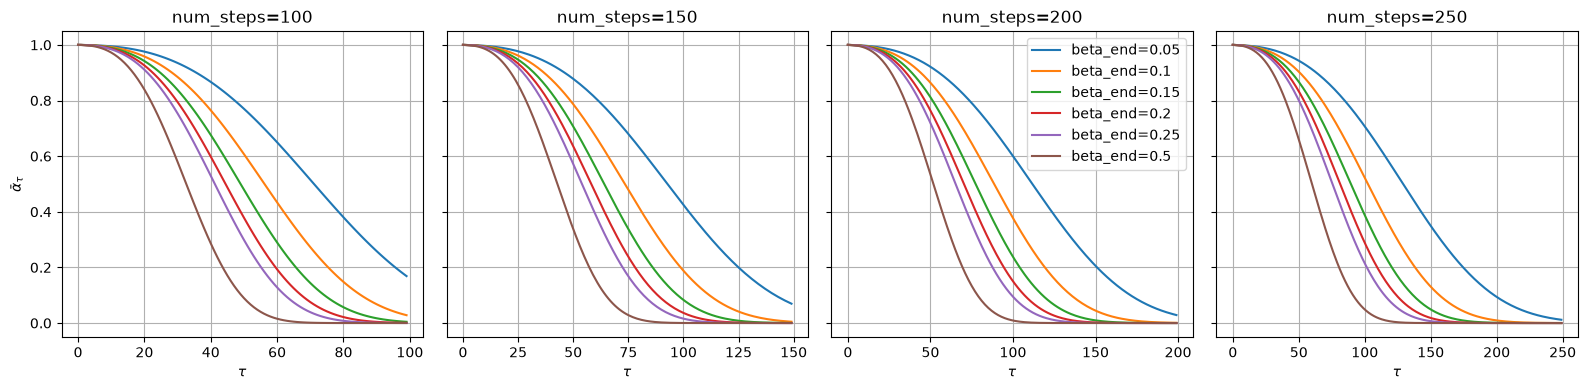

In [87]:
num_steps_list = [100, 150, 200, 250]
beta_ends = [0.05, 0.1, 0.15, 0.2, 0.25, 0.5]

fig, axs = plt.subplots(
    1, len(num_steps_list), figsize=(len(num_steps_list) * 4, 4), sharey=True
)

print("Final alpha_bar and sqrt(alpha_bar) values:")

for i, num_steps in enumerate(num_steps_list):
    print(f"\nnum_steps={num_steps}:")
    betas_list = [np.linspace(beta_start**0.5, end**0.5, num_steps) ** 2 for end in beta_ends]
    alphas_list = [1 - betas for betas in betas_list]
    alpha_bar_list = [np.cumprod(alphas) for alphas in alphas_list]

    print(
        [
            f"beta_end={beta_end}: {alpha_bar[-1]:.4g}, {np.sqrt(alpha_bar[-1]):.4g}"
            for alpha_bar, beta_end in zip(alpha_bar_list, beta_ends, strict=True)
        ]
    )

    for alpha_bar, end in zip(alpha_bar_list, beta_ends, strict=True):
        axs[i].plot(alpha_bar, label=f"beta_end={end}")
    axs[i].set_title(f"num_steps={num_steps}")
    axs[i].set_xlabel(r"$\tau$")
    if i == 0:
        axs[i].set_ylabel(r"$\bar{\alpha}_\tau$")
    axs[i].grid()

    if i == len(num_steps_list) // 2:
        axs[i].legend()

plt.tight_layout()
plt.show()

## Beta-clipping Investigation

In [1]:
import torch
import yaml

from src.config import Config
from src.data import load_ihdp
from src.model import DiffPO

/home/justin/msc_ai/individual-project/diffusion-irregular-ehr/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("config/ihdp.yaml") as f:
    cfg = Config.model_validate(yaml.safe_load(f))

train_ds, val_ds, _, y_std = load_ihdp(
    cfg.data.path,
    replication=cfg.data.replication,
    train_ratio=cfg.data.train_ratio,
    test_ratio=cfg.data.test_ratio,
)
print("y_std:", y_std)

a, y_fac, y_cf = train_ds.a, train_ds.y, train_ds.y_cf
y_both = torch.stack(
    [y_fac * (1 - a) + y_cf * a, y_fac * a + y_cf * (1 - a)], dim=1
)  # exact formula from _noise_targets

print("max abs:", y_both.abs().max().item())
print("mean/std:", y_both.mean().item(), y_both.std().item())
print("99.9th percentile:", y_both.abs().quantile(0.999).item())

y_std: 2.439351797103882
max abs: 3.009382486343384
mean/std: 0.19222968816757202 1.0039902925491333
99.9th percentile: 2.5268349647521973


In [3]:
model = DiffPO(cfg.model, cfg.diffusion)
sd = torch.load(
    "checkpoints/final_model_naive_full_2026-08-03T16_21_12.pth", map_location="cpu"
)
model.load_state_dict(sd)
model.eval()

B = 10
K = 1
x = val_ds.x[:B]
a = val_ds.a[:B]
x_rep = x.repeat_interleave(K, dim=0)
a_rep = a.repeat_interleave(K, dim=0)

In [14]:
BK = B * K

steps = range(model.L - 1, -1, -1)

CLIP_VAL = y_both.abs().max().item() * 2
print("CLIP_VAL:", CLIP_VAL)


def ddpm_reverse(clip_denoised: bool = False, clip_mu: bool = False):
    torch.manual_seed(0)
    y = torch.randn(BK, 2)

    eps_pred_list = []
    y_mean_list = []
    y_max_list = []

    with torch.no_grad():
        for step in steps:
            tau = torch.full((BK,), step, dtype=torch.long)

            eps_pred = model.denoiser(y, tau, x_rep, a_rep)
            alpha_bar = model.alpha_bar_sched[step]
            beta = model.beta_sched[step]
            alpha = model.alpha_sched[step]

            if clip_denoised:
                alpha_bar_safe = alpha_bar.clamp(min=1e-9)
                clean_pred = (y - (1.0 - alpha_bar_safe).sqrt() * eps_pred) / alpha_bar.sqrt()
                clean_pred = clean_pred.clamp(-CLIP_VAL, CLIP_VAL)

            mu = (1.0 / alpha.sqrt()) * (y - (beta / (1.0 - alpha_bar).sqrt()) * eps_pred)
            if clip_mu:
                mu = torch.clamp(mu, -CLIP_VAL, CLIP_VAL)

            if step > 0:
                alpha_bar_prev = model.alpha_bar_sched[step - 1]

                if clip_denoised:
                    mu = (alpha_bar_prev.sqrt() * beta / (1.0 - alpha_bar)) * clean_pred + (
                        (1.0 - alpha_bar_prev) * alpha.sqrt() / (1.0 - alpha_bar)
                    ) * y

                sigma = ((1.0 - alpha_bar_prev) / (1.0 - alpha_bar) * beta).sqrt()
                y = mu + sigma * torch.randn_like(mu)
            else:
                y = mu

            eps_pred_list.append(eps_pred.mean().item())
            y_mean_list.append(y.mean().item())
            y_max_list.append(y.max().item())

    # Return in reversed order to match the original time steps tau=0...L-1
    eps_pred_list.reverse()
    y_mean_list.reverse()
    y_max_list.reverse()
    return eps_pred_list, y_mean_list, y_max_list

CLIP_VAL: 6.018764972686768


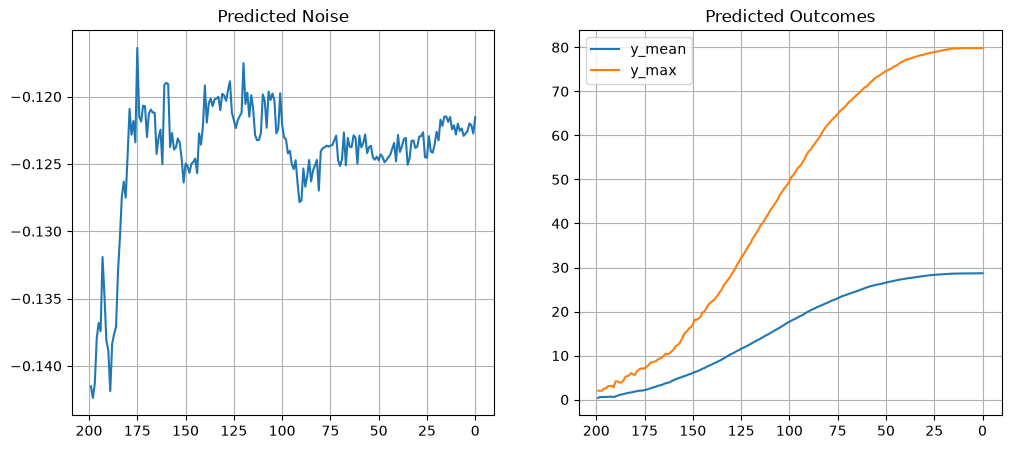

In [8]:
# No clipping

eps_pred_list, y_mean_list, y_max_list = ddpm_reverse()

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))

ax0.plot(eps_pred_list)
ax0.set_xlim(ax0.get_xlim()[::-1])
ax0.set_title("Predicted Noise")
ax0.grid()

ax1.plot(y_mean_list, label="y_mean")
ax1.plot(y_max_list, label="y_max")
ax1.set_xlim(ax1.get_xlim()[::-1])
ax1.set_title("Predicted Outcomes")
ax1.legend()
ax1.grid()

# plt.tight_layout()
plt.show()

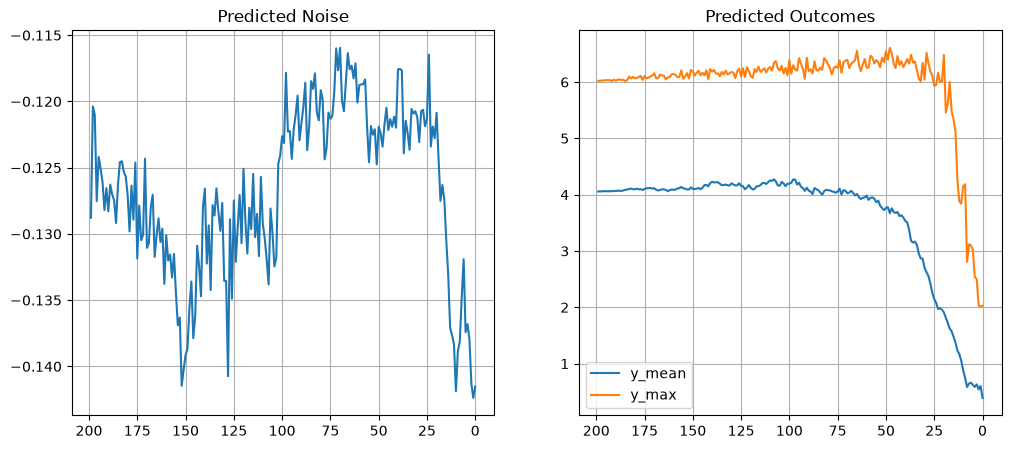

Step 99: y_mean=4.1956, y_max=6.3872
Step 89: y_mean=4.2537, y_max=6.2645
Step 79: y_mean=4.1231, y_max=6.1044
Step 69: y_mean=4.2004, y_max=6.1803
Step 59: y_mean=4.2297, y_max=6.1835
Step 49: y_mean=4.1024, y_max=6.1862
Step 39: y_mean=4.0867, y_max=6.1412
Step 29: y_mean=4.1142, y_max=6.1552
Step 19: y_mean=4.0957, y_max=6.0689
Step 9: y_mean=4.0677, y_max=6.0261
Step 0: y_mean=4.0567, y_max=6.0188


In [15]:
# Clip posterior mu

eps_pred_list, y_mean_list, y_max_list = ddpm_reverse(clip_mu=True)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))

ax0.plot(steps, eps_pred_list)
ax0.set_xlim(ax0.get_xlim()[::-1])
ax0.set_title("Predicted Noise")
ax0.grid()

ax1.plot(steps, y_mean_list, label="y_mean")
ax1.plot(steps, y_max_list, label="y_max")
ax1.set_xlim(ax1.get_xlim()[::-1])
ax1.set_title("Predicted Outcomes")
ax1.legend()
ax1.grid()

plt.show()

key_steps = range(9, 100, 10)
key_steps = [0] + list(key_steps)

y_mean_arr = np.array(y_mean_list)
y_max_arr = np.array(y_max_list)

for step in reversed(key_steps):
    print(f"Step {step}: y_mean={y_mean_arr[step]:.4f}, y_max={y_max_arr[step]:.4f}")

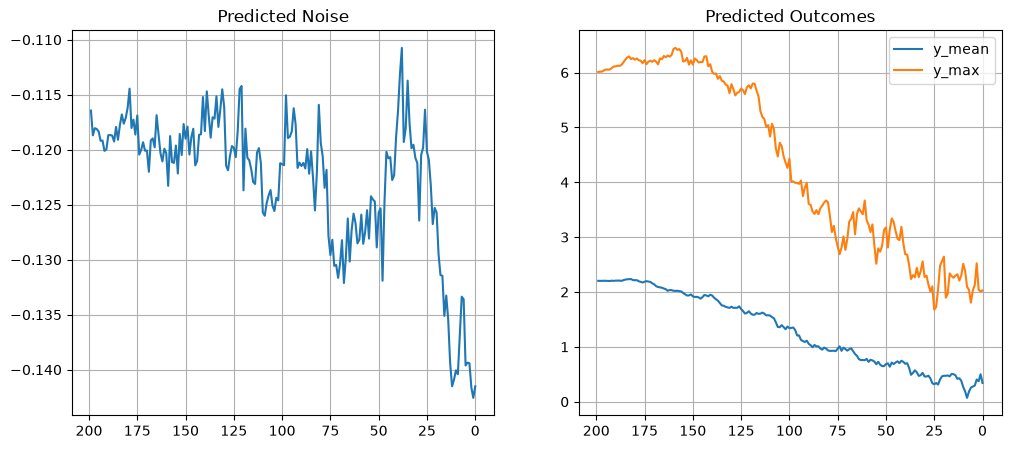

Step 99: y_mean=1.3402, y_max=4.4277
Step 89: y_mean=1.5695, y_max=4.8343
Step 79: y_mean=1.6071, y_max=5.7109
Step 69: y_mean=1.7313, y_max=5.7883
Step 59: y_mean=1.9365, y_max=6.0153
Step 49: y_mean=1.9200, y_max=6.1456
Step 39: y_mean=2.0225, y_max=6.4300
Step 29: y_mean=2.1382, y_max=6.2253
Step 19: y_mean=2.2141, y_max=6.2336
Step 9: y_mean=2.2070, y_max=6.1119
Step 0: y_mean=2.2030, y_max=6.0114


In [16]:
# Clip clean prediction

eps_pred_list, y_mean_list, y_max_list = ddpm_reverse(clip_denoised=True)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5))

ax0.plot(steps, eps_pred_list)
ax0.set_xlim(ax0.get_xlim()[::-1])
ax0.set_title("Predicted Noise")
ax0.grid()

ax1.plot(steps, y_mean_list, label="y_mean")
ax1.plot(steps, y_max_list, label="y_max")
ax1.set_xlim(ax1.get_xlim()[::-1])
ax1.set_title("Predicted Outcomes")
ax1.legend()
ax1.grid()

plt.show()

key_steps = range(9, 100, 10)
key_steps = [0] + list(key_steps)

y_mean_arr = np.array(y_mean_list)
y_max_arr = np.array(y_max_list)

for step in reversed(key_steps):
    print(f"Step {step}: y_mean={y_mean_arr[step]:.4f}, y_max={y_max_arr[step]:.4f}")